# **Project Name**    - Zomato Data Analysis and Clustering Model



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual


# **Project Summary -**


This project focuses on analyzing restaurant data collected from Zomato for the city of Hyderabad, with the objective of understanding restaurant characteristics, customer feedback patterns, and ultimately grouping restaurants into meaningful clusters based on their attributes and customer perception. The analysis uses two datasets: a restaurant metadata dataset containing 105 restaurants with details such as cost for two, cuisines offered, operating timings, and curated collections; and a customer reviews dataset containing 10,000 individual reviews across 100 restaurants, including review text, ratings, reviewer engagement metadata, and timestamps.

The first stage of the project involved understanding and cleaning both datasets independently. The metadata dataset required converting the cost column from a comma-separated text format into numeric values, and handling missing values in the collections and timings columns. The reviews dataset required removing duplicate entries, correcting an invalid non-numeric value found in the ratings column, and dropping rows with missing review text or ratings, since these could not be meaningfully used in later analysis.

Since the reviews dataset contains one row per individual review while the metadata dataset contains one row per restaurant, the reviews were aggregated at the restaurant level before merging. This involved calculating metrics such as the average rating per restaurant, the total number of reviews received, the variation in ratings (to capture how divided customer opinions were), and an average sentiment score derived from the review text using natural language processing techniques. This aggregated review summary was then merged with the restaurant metadata on restaurant name, producing a single unified dataset where each row represents one restaurant described both by its own attributes and by a summary of how customers responded to it.

Exploratory data analysis was carried out to understand distributions and relationships within the data, including the spread of restaurant costs, the most common cuisines offered, the distribution of average ratings, and how cost relates to customer sentiment. The cuisines column, originally a comma-separated text field, was converted into multiple binary indicator columns so that cuisine information could be used numerically in the clustering process. All numeric features were then standardized to ensure that variables measured on different scales, such as cost in rupees versus ratings out of five, contributed proportionally to the clustering algorithm rather than being dominated by variables with larger numeric ranges.

The core of the project is an unsupervised clustering model built to group restaurants with similar characteristics together, without using any predefined labels. The optimal number of clusters was determined using the elbow method and silhouette score, and K-Means clustering was implemented as the primary model, with Agglomerative Hierarchical Clustering used as a comparison model. Principal Component Analysis was used to reduce the feature space to two dimensions for visualization purposes, allowing the resulting clusters to be plotted and visually inspected. Each cluster was then interpreted by examining its average cost, rating, sentiment, and cuisine composition, in order to describe what kind of restaurant segment it represents in practical, business-relevant terms.

The outcome of this project is a set of restaurant segments that can help identify patterns such as premium restaurants with consistently positive sentiment, budget-friendly restaurants with high review volume, or restaurants with polarized customer opinions. These insights can support business decisions such as targeted marketing, identifying restaurants that may need service improvement, or understanding what combination of cost and cuisine tends to correlate with stronger customer satisfaction on the platform.


# **GitHub Link -**

https://github.com/adamaneeqaqwathka-arch/Zomato-Data-Analysis

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

#pandas used for data manipulation and analysis<br>
#numpy used for numerical computing<br>
#matplotlib.pyplot and seaborn used for data visualization


In [6]:
#importing libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [7]:
meta = pd.read_csv('../data/Zomato Restaurant names and Metadata.csv')
reviews = pd.read_csv('../data/Zomato Restaurant reviews.csv')

### Dataset First View

In [8]:
print("Metadata Dataset:")
display(meta.head())

print("Reviews Dataset:")
display(reviews.head())

Metadata Dataset:


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


Reviews Dataset:


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [9]:
### Dataset Rows & Columns count
print("Metadata Shape:")
print(f"Rows: {meta.shape[0]}, Columns: {meta.shape[1]}")
print("Reviews Shape:")
print(f"Rows: {reviews.shape[0]}, Columns: {reviews.shape[1]}")
#(rows, columns)

Metadata Shape:
Rows: 105, Columns: 6
Reviews Shape:
Rows: 10000, Columns: 7


### Dataset Information

In [10]:
print("Metadata Information:")
meta.info()

print("\nReviews Information:")
reviews.info()

Metadata Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.0+ KB

Reviews Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1),

#### Duplicate Values

In [11]:
print("Metadata duplicate rows:", meta.duplicated().sum())
print("Reviews duplicate rows:", reviews.duplicated().sum())

Metadata duplicate rows: 0
Reviews duplicate rows: 36


#### Missing Values/Null Values

In [12]:
print("Metadata Missing Values:")
print(meta.isnull().sum())

print("\nReviews Missing Values:")
print(reviews.isnull().sum())

Metadata Missing Values:
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

Reviews Missing Values:
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


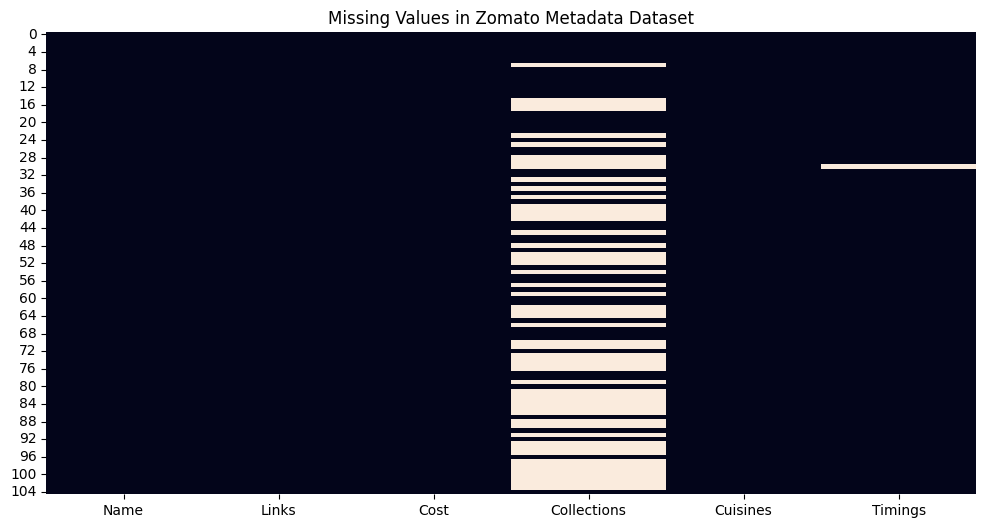

In [13]:
plt.figure(figsize=(12, 6))

sns.heatmap(meta.isnull(), cbar=False)

plt.title("Missing Values in Zomato Metadata Dataset")
plt.show()

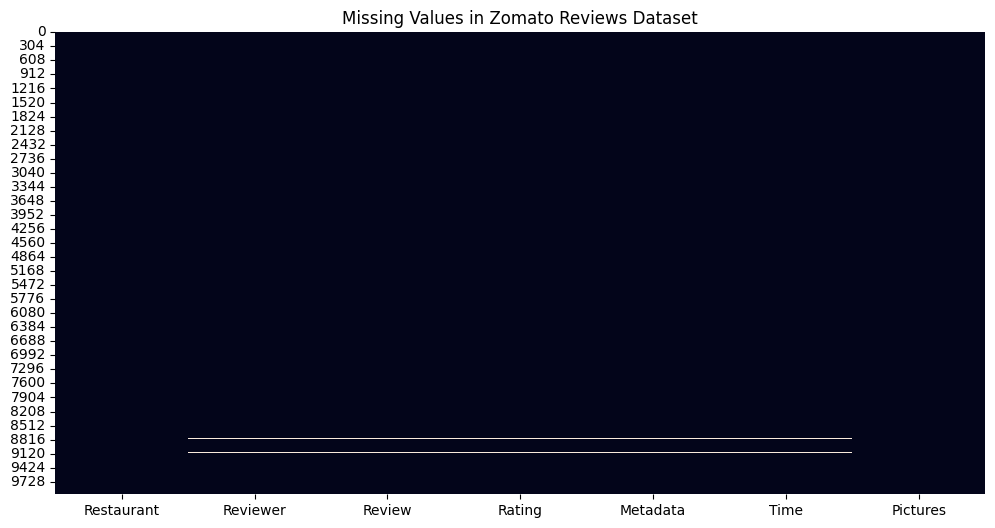

In [14]:
plt.figure(figsize=(12, 6))

sns.heatmap(reviews.isnull(), cbar=False)

plt.title("Missing Values in Zomato Reviews Dataset")
plt.show()

### What did you know about your dataset?


The Zomato dataset consists of **two datasets**: a **Restaurant Metadata dataset** and a **Restaurant Reviews dataset**. These datasets provide information about restaurants as well as customer reviews and ratings.

## 1. Restaurant Metadata Dataset

The Restaurant Metadata dataset contains information about **105 restaurants** and has **6 columns**:

* **Name**
* **Links**
* **Cost**
* **Collections**
* **Cuisines**
* **Timings**

The dataset contains **105 rows and 6 columns**. Some columns contain missing values, particularly the **Collections** column. The dataset does not contain completely duplicated rows.

## 2. Restaurant Reviews Dataset

The Restaurant Reviews dataset contains **10,000 customer reviews** across **7 columns**:

* **Restaurant**
* **Reviewer**
* **Review**
* **Rating**
* **Metadata**
* **Time** 
* **Pictures**

The reviews dataset contains reviews for **100 unique restaurants**. The ratings range from **1 to 5**, including half-star ratings such as **2.5, 3.5 and 4.5**.

The dataset contains some **duplicate records and missing values**, particularly in the Reviewer, Review, Rating, Metadata and Time columns. These values will need to be handled during the data-cleaning stage.

## 3. Important Observations

* The metadata dataset contains **105 restaurants**, while the reviews dataset contains reviews for **100 restaurants**.
* Therefore, **5 restaurants in the metadata dataset do not have corresponding reviews in the reviews dataset**.
* The reviews dataset contains **10,000 reviews**, providing a substantial amount of customer feedback for analysis.
* The **Rating** column can be used to analyze customer satisfaction.
* The **Review** column can be used for **sentiment analysis or text analysis**.
* The **Cuisines** column can be used to study popular cuisine types.
* The **Cost** column can be analyzed to understand restaurant pricing after converting it into a suitable numerical format.
* The **Timings** column can be used to analyze restaurant operating hours.
* The metadata and reviews datasets can potentially be combined using the **restaurant name** to perform more detailed restaurant-level analysis.

## 4. Overall Understanding

Overall, this dataset can be used to understand **restaurant characteristics, pricing, cuisines, customer ratings and customer opinions**. After cleaning the missing and duplicate values, the data can be used for **Exploratory Data Analysis (EDA), visualization, sentiment analysis and restaurant clustering**.

The dataset provides a good foundation for identifying **patterns in restaurant preferences, customer satisfaction and restaurant characteristics**.


## ***2. Understanding Your Variables***

In [15]:
# Columns in Metadata Dataset
print("Metadata Dataset Columns:")
print(meta.columns)

print("\nMetadata Dataset Shape:")
print(meta.shape)

# Columns in Reviews Dataset
print("\nReviews Dataset Columns:")
print(reviews.columns)

print("\nReviews Dataset Shape:")
print(reviews.shape)

Metadata Dataset Columns:
Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

Metadata Dataset Shape:
(105, 6)

Reviews Dataset Columns:
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

Reviews Dataset Shape:
(10000, 7)


In [16]:
# Statistical description of Metadata Dataset
meta.describe(include='all')



,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


In [17]:
# Statistical description of Reviews Dataset
reviews.describe(include='all')

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


### Variables Description

## Understanding Your Variables

The Zomato dataset consists of two datasets: **Restaurant Metadata** and **Restaurant Reviews**.

### Restaurant Metadata

The Metadata dataset contains **105 rows and 6 columns**. It provides information about restaurants, including:

* **Name** – Name of the restaurant.
* **Links** – Zomato link of the restaurant.
* **Cost** – Approximate cost of dining at the restaurant.
* **Collections** – Zomato collections or categories associated with the restaurant.
* **Cuisines** – Types of cuisines offered by the restaurant.
* **Timings** – Operating hours of the restaurant.

Most of the variables in this dataset are **categorical/textual variables**. The `Cost` column may require preprocessing before numerical analysis.

### Restaurant Reviews

The Reviews dataset contains **10,000 rows and 7 columns**. It provides customer feedback and information about restaurant reviews.

The variables are:

* **Restaurant** – Name of the restaurant being reviewed.
* **Reviewer** – Name of the customer who posted the review.
* **Review** – Textual feedback provided by the customer.
* **Rating** – Rating given by the customer.
* **Metadata** – Additional information related to the reviewer.
* **Time** – Date and time when the review was posted.
* **Pictures** – Number of pictures associated with the review.

The `Rating` and `Pictures` variables are numerical, while most of the remaining variables contain categorical or textual information.

### Overall Understanding

The variables in these datasets can be used to analyze different aspects of restaurants, such as **restaurant popularity, customer satisfaction, pricing, cuisines, operating hours and customer opinions**.

The `Review` column can be used for text or sentiment analysis, while the `Rating` column can be used to study customer satisfaction. The restaurant metadata can also be combined with review information to perform restaurant-level analysis.


### Check Unique Values for each variable.

In [18]:
meta.nunique().sort_values(ascending=False).reset_index().rename(
    columns={'index': 'Column Name', 0: 'Unique Value Count'}
)

,Column Name,Unique Value Count
0,Name,105
1,Links,105
2,Cuisines,92
3,Timings,77
4,Collections,42
5,Cost,29


In [19]:
reviews.nunique().sort_values(ascending=False).reset_index().rename(
    columns={'index': 'Column Name', 0: 'Unique Value Count'}
)

,Column Name,Unique Value Count
0,Time,9782
1,Review,9364
2,Reviewer,7446
3,Metadata,2477
4,Restaurant,100
5,Pictures,36
6,Rating,10


## 3. ***Data Wrangling***

### Data Wrangling Code

In [20]:
# =========================================================
# Data Wrangling — Cleaning, Feature Extraction & Merging
# =========================================================

# Make copies so the original datasets remain unchanged
meta_clean = meta.copy()
reviews_clean = reviews.copy()

# -------------------------------
# 1. Remove duplicate rows
# -------------------------------
meta_clean.drop_duplicates(inplace=True)
reviews_clean.drop_duplicates(inplace=True)

# -------------------------------
# 2. Clean the Metadata dataset
# -------------------------------

# Cost: remove commas, convert to numeric
meta_clean['Cost'] = meta_clean['Cost'].str.replace(',', '').astype(float)

# Timings: fill the single missing value with the most common timing (mode)
meta_clean['Timings'] = meta_clean['Timings'].fillna(meta_clean['Timings'].mode()[0])

# Collections: over 50% missing, so we drop it rather than impute noise
missing_pct = meta_clean['Collections'].isnull().mean() * 100
print(f"Collections missing: {missing_pct:.2f}% -> dropping column")
meta_clean.drop(columns=['Collections'], inplace=True)

# -------------------------------
# 3. Clean the Reviews dataset
# -------------------------------

# Rating: 'Like' and other non-numeric values become NaN
reviews_clean['Rating'] = pd.to_numeric(reviews_clean['Rating'], errors='coerce')

# Time: convert to proper datetime
reviews_clean['Time'] = pd.to_datetime(reviews_clean['Time'], errors='coerce')

# Extract real numeric features out of the 'Metadata' text column
# e.g. "3 Reviews , 2 Followers" -> Total_Reviewer_Reviews=3, Total_Reviewer_Followers=2
reviews_clean[['Total_Reviewer_Reviews', 'Total_Reviewer_Followers']] = (
    reviews_clean['Metadata'].str.split(',', n=1, expand=True)
)
reviews_clean['Total_Reviewer_Reviews'] = pd.to_numeric(
    reviews_clean['Total_Reviewer_Reviews'].str.extract(r'(\d+)')[0]
)
reviews_clean['Total_Reviewer_Followers'] = pd.to_numeric(
    reviews_clean['Total_Reviewer_Followers'].str.extract(r'(\d+)')[0]
)
reviews_clean['Total_Reviewer_Followers'] = reviews_clean['Total_Reviewer_Followers'].fillna(0)

# Drop rows with no rating or no review text — nothing usable to salvage there
reviews_clean.dropna(subset=['Rating', 'Review'], inplace=True)

# -------------------------------
# 4. Aggregate reviews to restaurant level
#    (10,000 review-rows -> 1 row per restaurant)
# -------------------------------
review_summary = reviews_clean.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Num_Reviews=('Rating', 'count'),
    Rating_Std=('Rating', 'std'),
    Avg_Reviewer_Followers=('Total_Reviewer_Followers', 'mean'),
    Total_Pictures=('Pictures', 'sum')
).reset_index()

# A restaurant with only 1 review has no std deviation (NaN) -> treat as 0 (no disagreement)
review_summary['Rating_Std'] = review_summary['Rating_Std'].fillna(0)

# -------------------------------
# 5. Merge metadata with the aggregated review summary
# -------------------------------
df = meta_clean.merge(review_summary, left_on='Name', right_on='Restaurant', how='inner')
df.drop(columns=['Restaurant'], inplace=True)  # redundant, same as 'Name'

# -------------------------------
# 6. Check the final merged dataset
# -------------------------------
print("Final merged dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Collections missing: 51.43% -> dropping column
Final merged dataset shape: (100, 10)

Missing values:
 Name                      0
Links                     0
Cost                      0
Cuisines                  0
Timings                   0
Avg_Rating                0
Num_Reviews               0
Rating_Std                0
Avg_Reviewer_Followers    0
Total_Pictures            0
dtype: int64


,Name,Links,Cost,Cuisines,Timings,Avg_Rating,Num_Reviews,Rating_Std,Avg_Reviewer_Followers,Total_Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",4.28,100,1.239746,100.61,39
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800.0,"Biryani, North Indian, Chinese",11 AM to 11 PM,4.70,100,0.771984,7.98,2
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300.0,"Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4.66,100,0.878704,27.48,55
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800.0,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,3.21,100,1.603626,118.43,30
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200.0,"Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",4.34,100,1.065719,70.10,44


### What all manipulations have you done and insights you found?

### What All Manipulations Have You Done and Insights You Found?

#### Data Manipulations Performed

1. **Created copies of the original datasets** to preserve the original data while performing cleaning and transformations.

2. **Removed duplicate records** from both the Metadata and Reviews datasets to avoid repeated information affecting the analysis.

3. **Cleaned the `Cost` column** by removing commas and converting the values from text into numerical format, making the variable suitable for numerical analysis.

4. **Handled missing values in `Timings`** by replacing the missing value with the most frequently occurring timing.

5. **Removed the `Collections` column** from the Metadata dataset because more than 50% of its values were missing. Keeping the column could introduce unreliable information into the analysis.

6. **Converted the `Rating` column into numerical format**. Non-numeric values such as `Like` were converted to missing values so that the ratings could be used for statistical calculations.

7. **Converted the `Time` column into datetime format** to make it suitable for time-based analysis.

8. **Extracted useful numerical features from the `Metadata` column** of the Reviews dataset. The reviewer metadata was split to obtain:

   * `Total_Reviewer_Reviews`
   * `Total_Reviewer_Followers`

9. **Handled missing reviewer follower values** by replacing them with `0`.

10. **Removed reviews without valid ratings or review text** because these records could not provide useful information for rating and review analysis.

11. **Aggregated individual reviews at the restaurant level**. Instead of treating every review as a separate observation, review information was summarized for each restaurant using:

* `Avg_Rating`
* `Num_Reviews`
* `Rating_Std`
* `Avg_Reviewer_Followers`
* `Total_Pictures`

12. **Handled missing standard deviation values** by replacing them with `0` for restaurants with insufficient reviews to calculate rating variation.

13. **Merged the Metadata and Review Summary datasets** using the restaurant name, creating a single restaurant-level dataset for further analysis.

#### Insights Found

* The original datasets contain information about **restaurant characteristics as well as customer experiences**.
* The Reviews dataset contains thousands of individual reviews, so aggregating them by restaurant provides a more meaningful dataset for restaurant-level analysis.
* `Avg_Rating` represents the overall customer satisfaction for each restaurant.
* `Num_Reviews` provides an indication of the amount of customer feedback available for a restaurant.
* `Rating_Std` can help identify restaurants where customer opinions are consistent or highly varied.
* `Avg_Reviewer_Followers` provides an indication of the average social reach of the reviewers.
* `Total_Pictures` can provide an indication of customer engagement with a restaurant.
* Removing the highly incomplete `Collections` column reduces the possibility of introducing unreliable information.
* Converting `Cost` and `Rating` into numerical variables makes them suitable for statistical analysis and machine learning.
* The final merged dataset provides **restaurant-level features combining restaurant characteristics and customer feedback**.
* This cleaned and aggregated dataset is suitable for further **Exploratory Data Analysis, visualization and restaurant clustering**.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Distribution of Numerical Variables

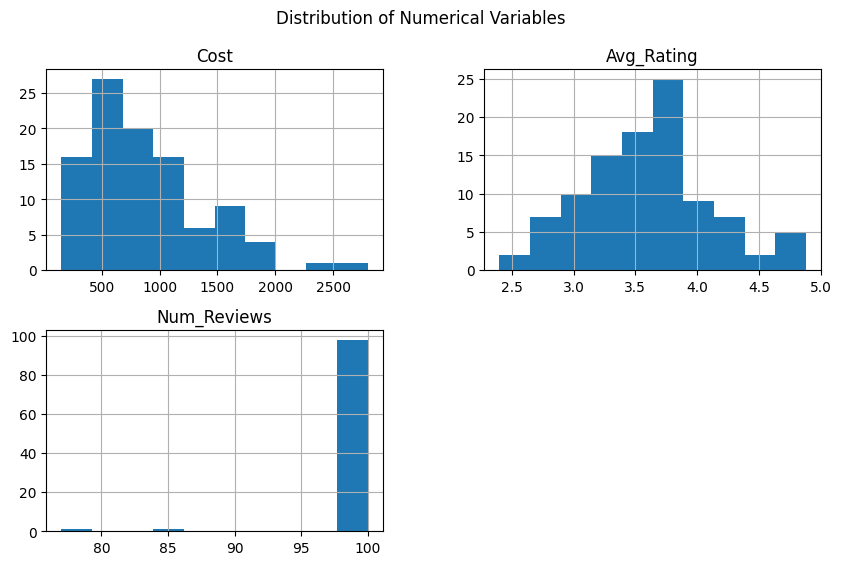

In [21]:
df[['Cost', 'Avg_Rating', 'Num_Reviews']].hist(
    figsize=(10, 6)
)

plt.suptitle('Distribution of Numerical Variables')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was selected to understand the distribution of the important numerical variables such as Cost, Average Rating and Number of Reviews. It helps identify the common ranges and spread of the data.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the numerical variables have different distributions. Restaurant cost is concentrated within certain price ranges, while ratings are mostly concentrated around the middle-to-high rating range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of cost and ratings can help Zomato categorize restaurants into different price and quality segments and provide better recommendations to customers.

There can be negative business impact if restaurants are concentrated in only a few price or rating ranges, as customers may have fewer choices in other segments.

#### Chart - 2 Top 10 Expensive Restaurants

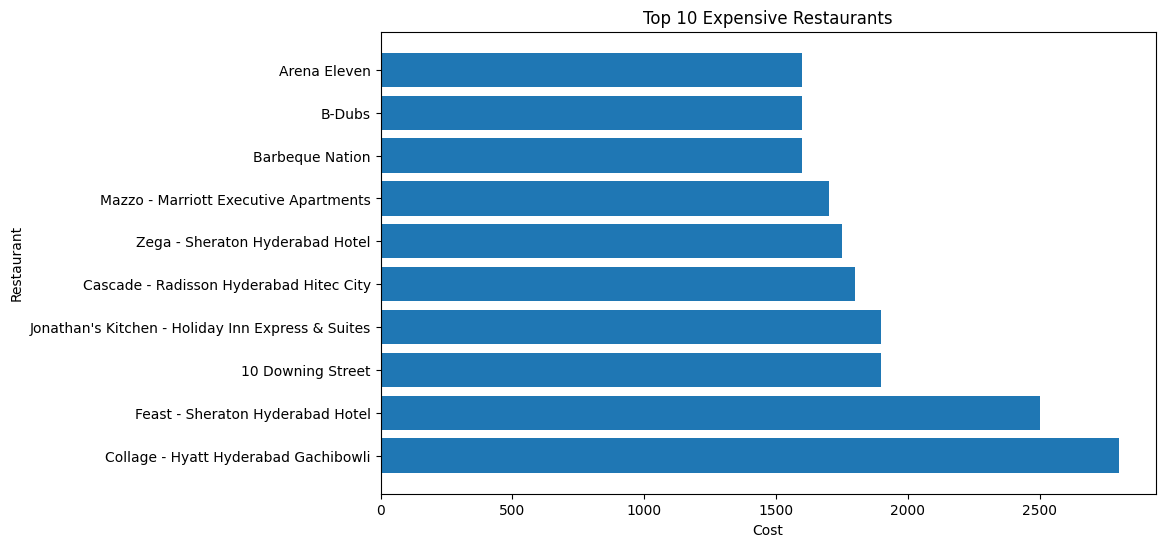

In [22]:
top10 = df.nlargest(10, 'Cost')

plt.figure(figsize=(10, 6))

plt.barh(top10['Name'], top10['Cost'])

plt.xlabel('Cost')
plt.ylabel('Restaurant')
plt.title('Top 10 Expensive Restaurants')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it makes it easy to compare the cost of the most expensive restaurants.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the 10 restaurants with the highest average cost in the dataset. These restaurants represent the premium end of the restaurant market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Zomato can use this information to create premium restaurant categories and provide recommendations for customers looking for high-end dining experiences.

The higher cost may negatively affect demand from budget-conscious customers. Therefore, expensive restaurants may need to provide additional value through food quality and service.

#### Chart - 3 Top 10 Affordable Restaurants

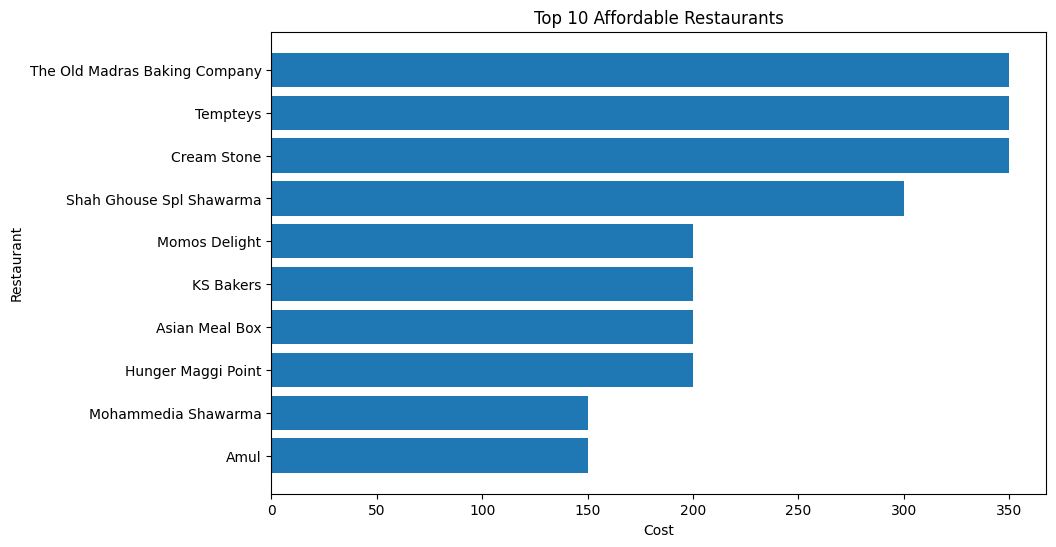

In [23]:
top10 = df.nsmallest(10, 'Cost')

plt.figure(figsize=(10, 6))

plt.barh(top10['Name'], top10['Cost'])

plt.xlabel('Cost')
plt.ylabel('Restaurant')
plt.title('Top 10 Affordable Restaurants')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected to easily compare the restaurants with the lowest average cost.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the 10 most affordable restaurants in the dataset. These restaurants provide lower-cost dining options compared with the other restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Zomato can use this information to provide budget-friendly recommendations and attract customers who are more price-sensitive.

A possible negative impact is that very low pricing may create lower profit margins for restaurants if the pricing is not balanced with operating costs.

#### Chart - 4 Restaurants by Number of Cuisines

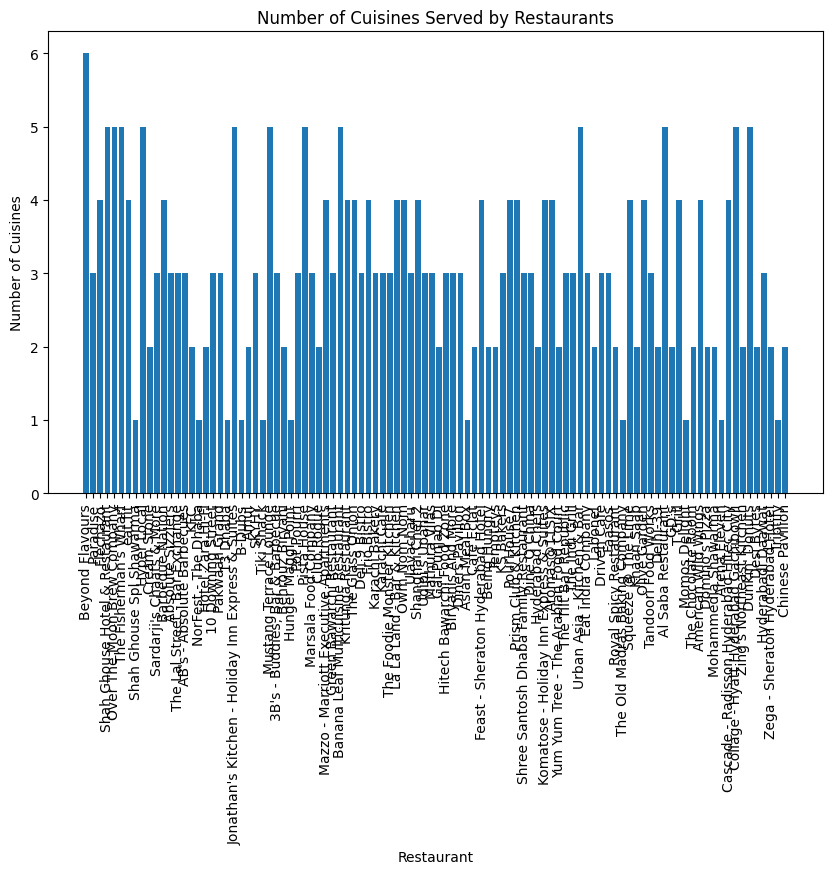

In [24]:
df['Cuisine_Count'] = df['Cuisines'].str.count(',') + 1 # creating number of cuisines column
plt.figure(figsize=(10, 6))

plt.bar(df['Name'], df['Cuisine_Count'])

plt.xlabel('Restaurant')
plt.ylabel('Number of Cuisines')
plt.title('Number of Cuisines Served by Restaurants')

plt.xticks(rotation=90)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare the number of cuisines offered by different restaurants.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that restaurants differ in their cuisine variety. Some restaurants specialize in a small number of cuisines, while others offer a wider range of cuisines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurants offering multiple cuisines can attract customers with different food preferences, while specialized restaurants can focus on a specific target audience.

Offering too many cuisines may negatively affect food quality and operational efficiency if the restaurant cannot maintain consistency across all cuisines.

#### Chart - 5 Cost vs Reviewer Followers

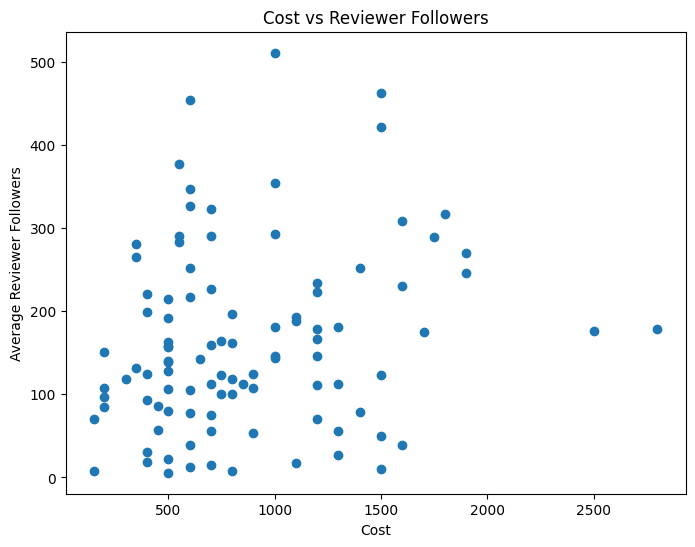

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Cost'],
    df['Avg_Reviewer_Followers']
)

plt.xlabel('Cost')
plt.ylabel('Average Reviewer Followers')
plt.title('Cost vs Reviewer Followers')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected because it helps visualize the relationship between restaurant cost and average reviewer followers.

##### 2. What is/are the insight(s) found from the chart?

The chart helps determine whether restaurants with higher costs are associated with reviewers who have a larger follower base. The relationship does not necessarily mean that one variable causes the other.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding reviewer influence can help restaurants and Zomato identify opportunities for influencer-based promotion.

Relying too heavily on high-follower reviewers can be a negative strategy because follower count does not necessarily represent the quality or reliability of a review.

#### Chart - 6 Top 10 Reviewers

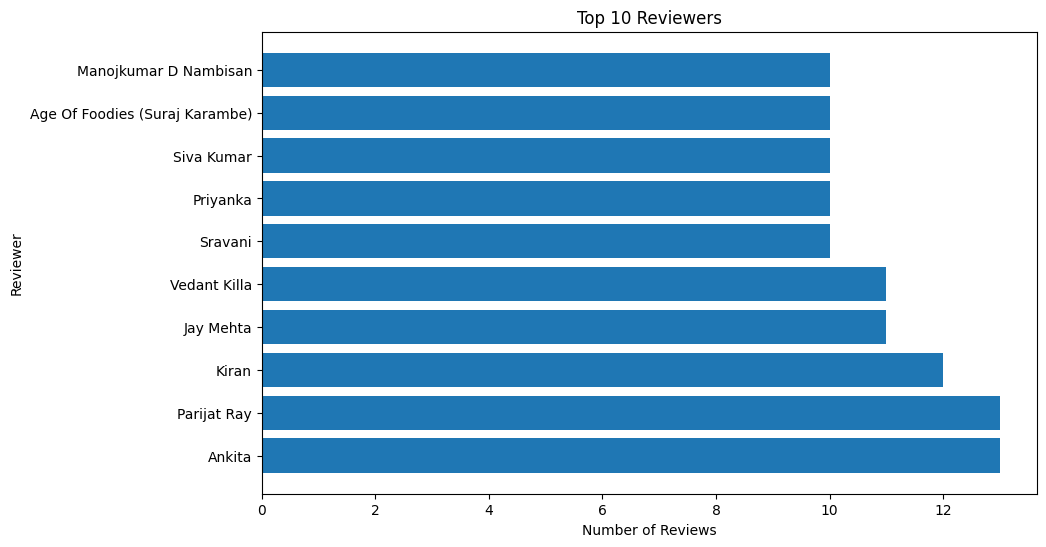

In [26]:
reviewer_count = reviews_clean['Reviewer'].value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    reviewer_count.index,
    reviewer_count.values
)

plt.xlabel('Number of Reviews')
plt.ylabel('Reviewer')
plt.title('Top 10 Reviewers')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected to identify the reviewers who have submitted the highest number of reviews.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the most active reviewers in the dataset. These reviewers contribute a larger amount of customer feedback than other reviewers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Active reviewers can provide valuable feedback and help Zomato understand customer experiences.

However, relying heavily on a small number of reviewers can create biased results because their opinions may not represent the majority of customers.

#### Chart - 7 Cost According to Rating Across 4 Years

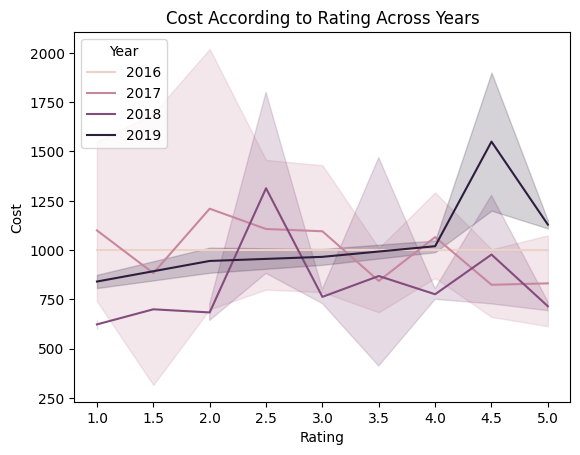

In [27]:
reviews_clean['Year'] = reviews_clean['Time'].dt.year #creting year

#merging cost 
year_data = reviews_clean.merge(
    meta_clean[['Name', 'Cost']],
    left_on='Restaurant',
    right_on='Name'
)

year_data = year_data[
    year_data['Year'].isin([2016, 2017, 2018, 2019])
]

sns.lineplot(
    data=year_data,
    x='Rating',
    y='Cost',
    hue='Year'
)

plt.title('Cost According to Rating Across Years')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected to compare the relationship between restaurant cost and customer rating across different years.

##### 2. What is/are the insight(s) found from the chart?

The chart helps identify whether the relationship between restaurant pricing and customer ratings changed between 2016 and 2019.

It also helps determine whether higher-rated restaurants consistently belonged to higher or lower price segments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding changes in customer ratings and restaurant costs over time can help restaurants evaluate their pricing strategy.

A negative impact may occur if increasing prices does not result in better customer satisfaction, as customers may perceive the restaurant as offering poor value for money.

#### Chart - 8 Cuisine Count Across 4 Years

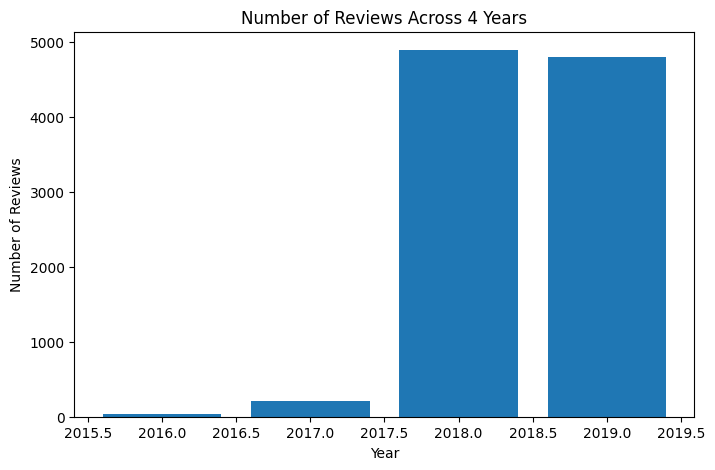

In [28]:
year_count = reviews_clean['Year'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    year_count.index,
    year_count.values
)

plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews Across 4 Years')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare the number of reviews available for each year.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how review activity is distributed across the four years. Some years have more reviews than others, indicating differences in the amount of data available for each period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding review activity over time can help identify periods of higher customer engagement.

However, if some years contain very few reviews, comparisons between years may not be reliable and could lead to incorrect business conclusions.

#### Chart - 9 Cost Across Different Cuisines

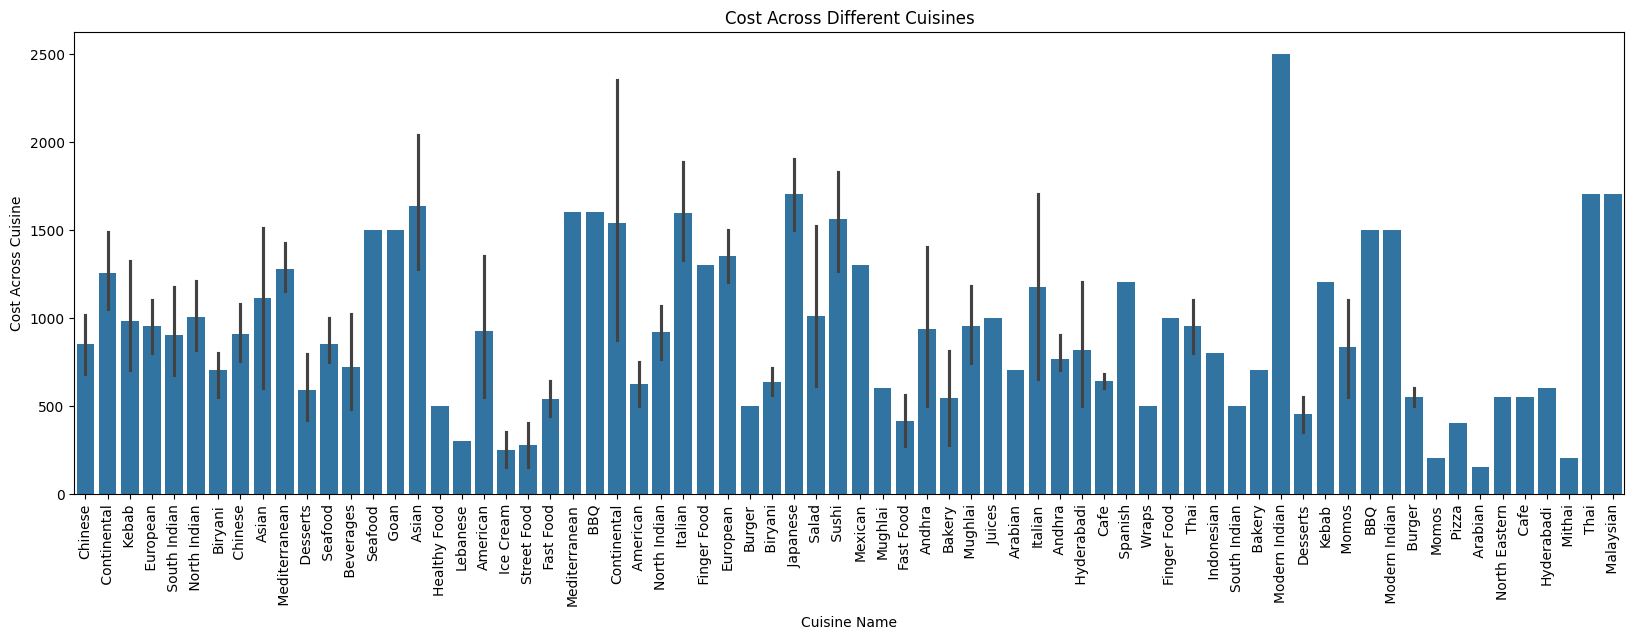

In [29]:
# Chart - 9 visualization code

df_9 = meta_clean.copy()

df_9['Cuisines'] = df_9['Cuisines'].str.split(',')
df_9 = df_9.explode('Cuisines')

df_9['Cost'] = df_9['Cost'].astype(int)

plt.figure(figsize=(20, 6))

sns.barplot(
    data=df_9,
    x='Cuisines',
    y='Cost'
)

plt.title('Cost Across Different Cuisines')
plt.xlabel('Cuisine Name')
plt.ylabel('Cost Across Cuisine')

plt.xticks(rotation=90)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare the average cost associated with the different cuisines available in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the average cost differs across cuisines. Some cuisines are associated with relatively higher-priced restaurants, while others are more affordable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This information can help Zomato create cuisine-and-price-based recommendations and help restaurants understand their position within their cuisine category.

Higher-priced cuisines may reduce demand from budget-conscious customers, while very low pricing may affect restaurant profitability.

#### Chart - 10— Top 5 Restaurants by Reviewer Influence

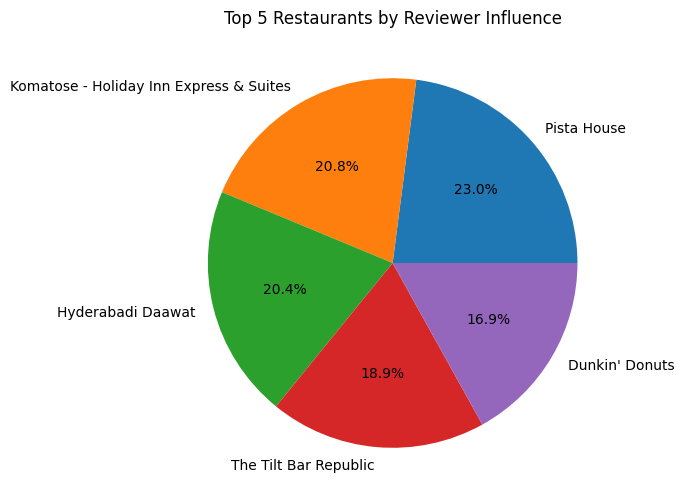

In [30]:
top5 = df.nlargest(5, 'Avg_Reviewer_Followers')

plt.figure(figsize=(8, 6))

plt.pie(
    top5['Avg_Reviewer_Followers'],
    labels=top5['Name'],
    autopct='%1.1f%%'
)

plt.title('Top 5 Restaurants by Reviewer Influence')

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was selected to show the relative share of reviewer influence among the top five restaurants.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the restaurants associated with reviewers having the highest average follower counts. It shows the relative contribution of reviewer influence among these restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurants receiving attention from influential reviewers may gain greater online visibility and customer awareness.

However, depending too much on influencer exposure can be risky because follower count does not guarantee positive customer experiences or long-term customer loyalty.

#### Chart - 11 Bottom 5 Restaurants by Reviewer Influence

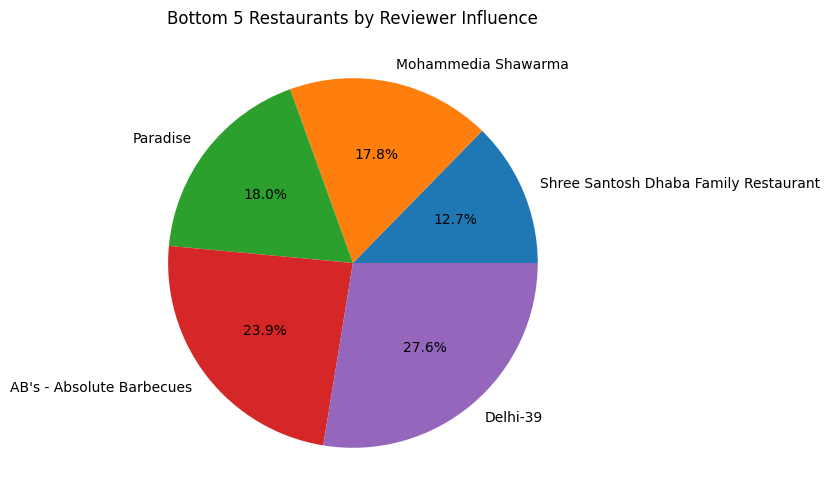

In [31]:
bottom5 = df.nsmallest(5, 'Avg_Reviewer_Followers')

plt.figure(figsize=(8, 6))

plt.pie(
    bottom5['Avg_Reviewer_Followers'],
    labels=bottom5['Name'],
    autopct='%1.1f%%'
)

plt.title('Bottom 5 Restaurants by Reviewer Influence')

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was selected to compare the relative reviewer influence associated with the bottom five restaurants.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies restaurants associated with reviewers having relatively lower follower counts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These restaurants may have an opportunity to improve their online visibility through better digital marketing and customer engagement.

Lower reviewer influence can lead to less social-media exposure and may make it more difficult for smaller restaurants to attract new customers.

#### Chart - 12 Review Activity Across Months

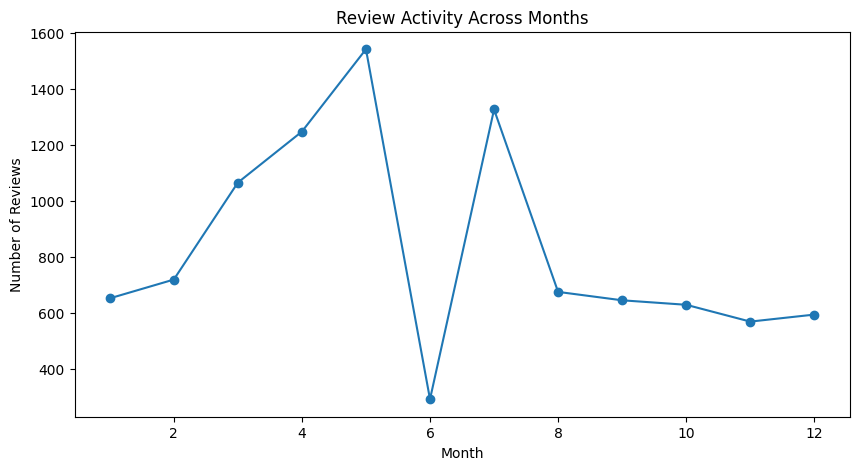

In [32]:
reviews_clean['Month'] = reviews_clean['Time'].dt.month

month_count = reviews_clean['Month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    month_count.index,
    month_count.values,
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.title('Review Activity Across Months')

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because months represent an ordered sequence and a line chart makes changes in review activity easier to observe.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how the number of reviews changes across different months. It can help identify months with relatively high or low customer review activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurants can use seasonal customer activity patterns to plan promotions, offers and marketing campaigns.

Low review activity during certain months may indicate lower customer engagement, which could require targeted promotions.

#### Chart - 13 Top 10 Zomato Collections

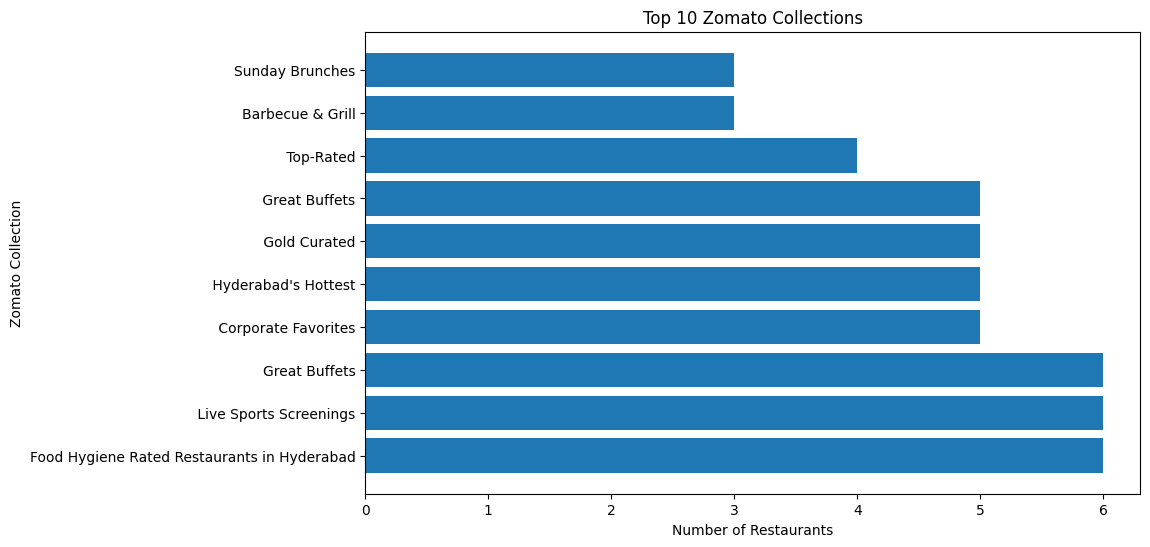

In [33]:
collections = meta['Collections'].dropna()

collections = collections.str.split(',').explode()

top10 = collections.value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10.index,
    top10.values
)

plt.xlabel('Number of Restaurants')
plt.ylabel('Zomato Collection')
plt.title('Top 10 Zomato Collections')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected to compare the number of restaurants belonging to different Zomato collections.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the Zomato collections that contain the largest number of restaurants. It provides an understanding of how restaurants are categorized on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding popular restaurant collections can help Zomato improve category-based discovery and recommendation systems.

A collection with very few restaurants may have limited usefulness to customers if it does not provide enough choices.

Note: The dataset does not contain revenue information, so the chart measures the number of restaurants in each collection, not revenue generated by the collection.

#### Chart - 14 Correlation Heatmap

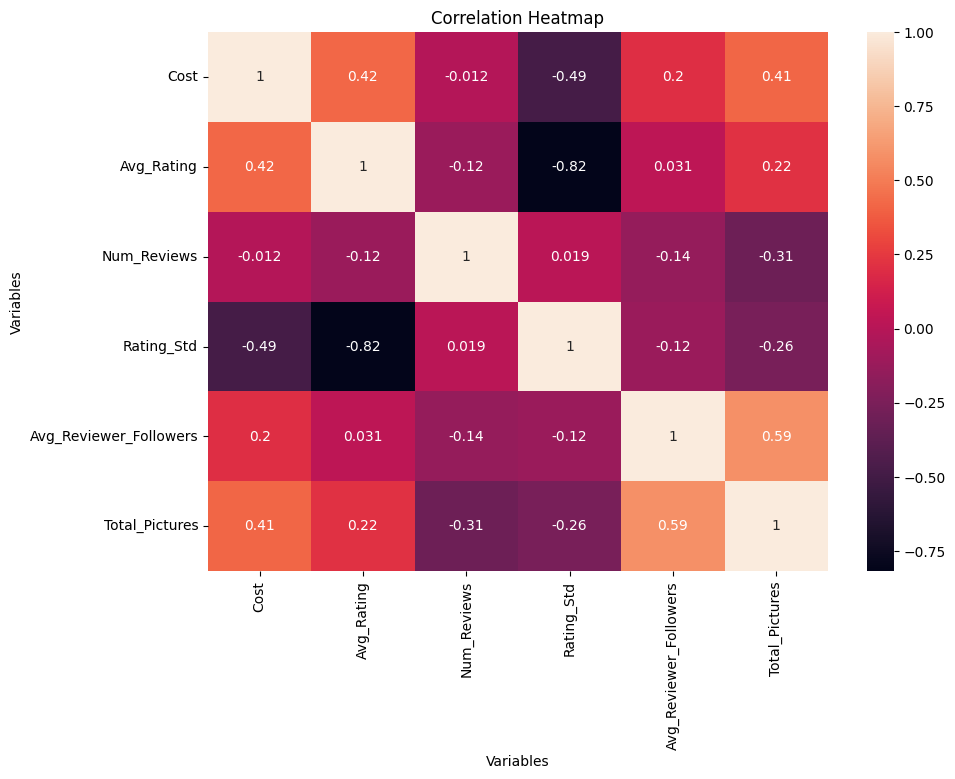

In [34]:
numeric_data = df[
    [
        'Cost',
        'Avg_Rating',
        'Num_Reviews',
        'Rating_Std',
        'Avg_Reviewer_Followers',
        'Total_Pictures'
    ]
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_data.corr(),
    annot=True
)

plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('Correlation Heatmap')

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected to understand the strength and direction of relationships between the important numerical variables.

##### 2. What is/are the insight(s) found from the chart?

The heatmap helps identify positive and negative relationships between variables such as Cost, Average Rating, Number of Reviews, Rating Standard Deviation, Reviewer Followers and Total Pictures.

A strong correlation indicates that two variables tend to change together, while a weak correlation indicates little linear relationship.

#### Chart - 15 - Pair Plot

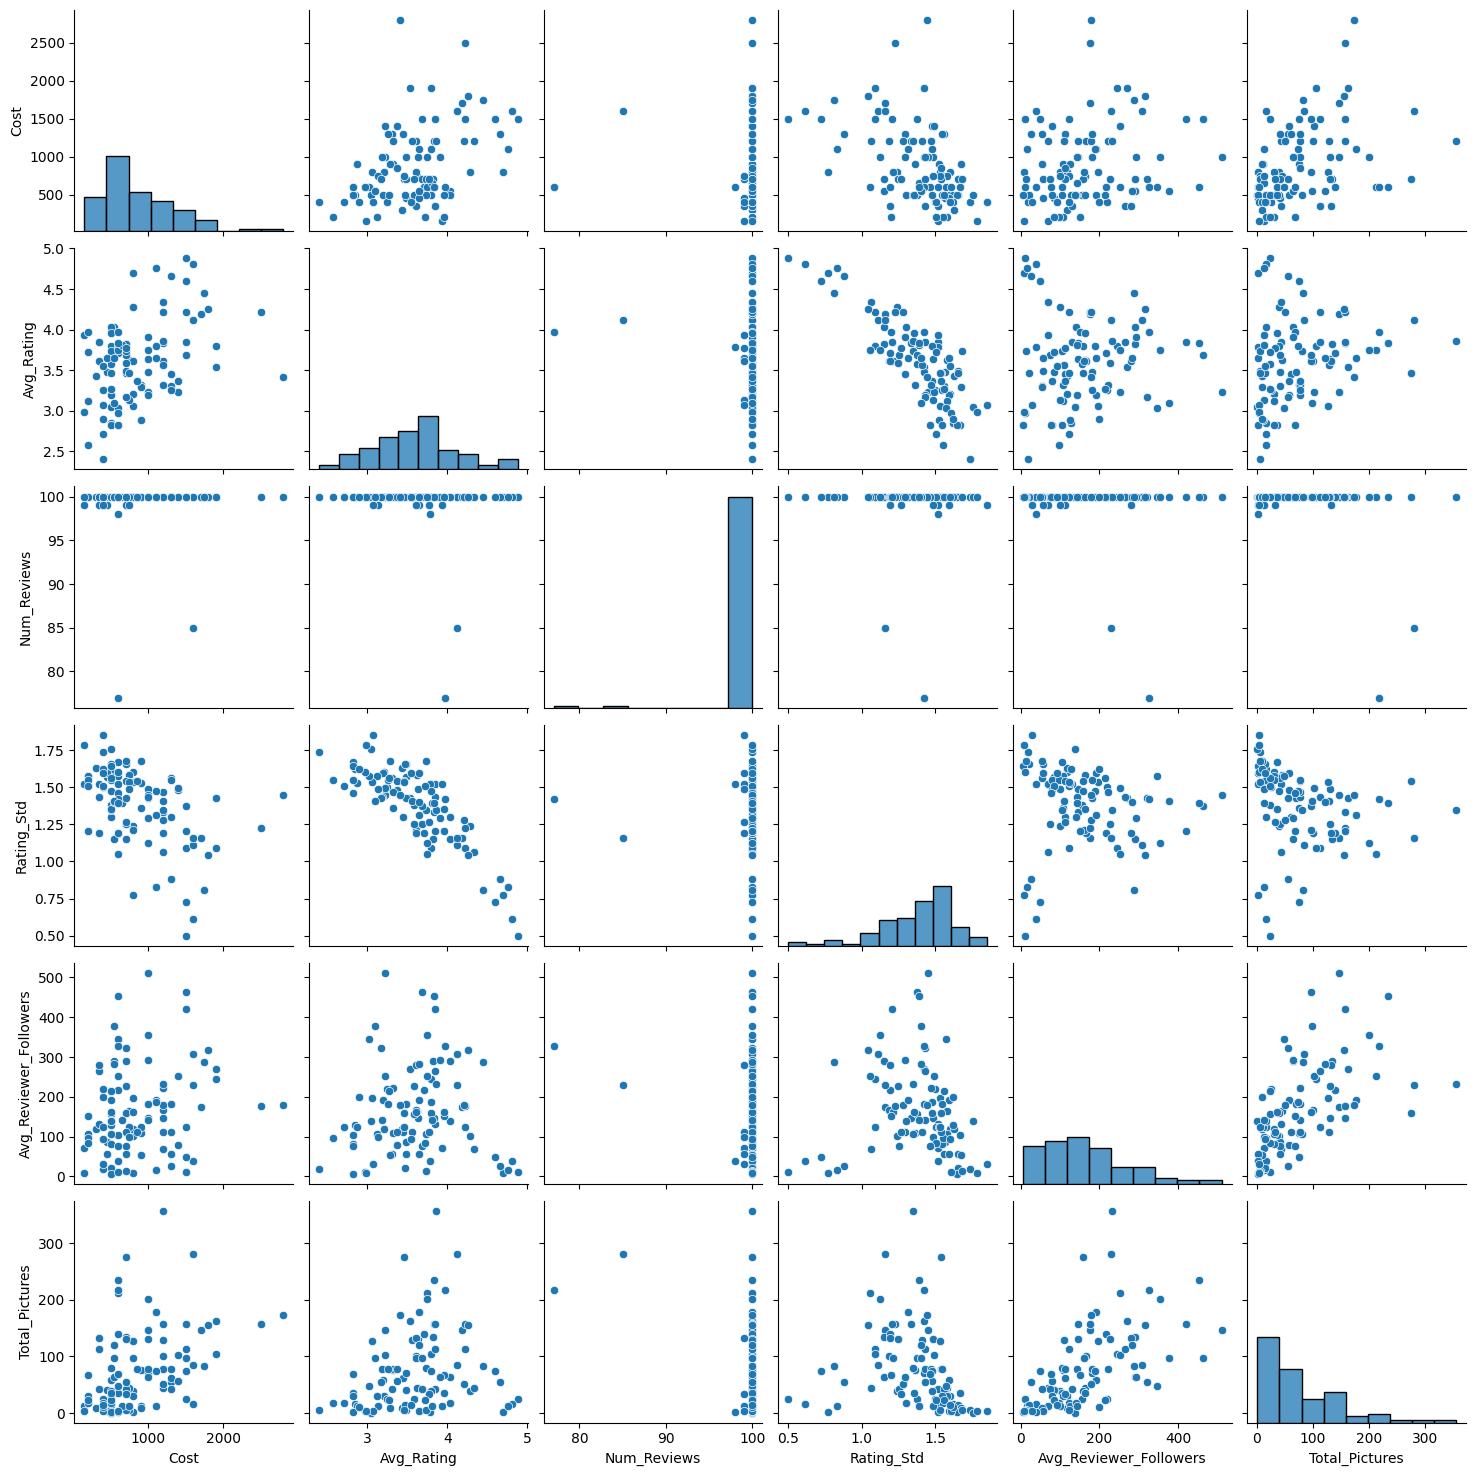

In [35]:
sns.pairplot(
    df[
        [
            'Cost',
            'Avg_Rating',
            'Num_Reviews',
            'Rating_Std',
            'Avg_Reviewer_Followers',
            'Total_Pictures'
        ]
    ]
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was selected because it allows us to examine the relationships between multiple numerical variables at the same time. It also shows the distribution of each variable.

##### 2. What is/are the insight(s) found from the chart?

The pair plot helps identify positive and negative relationships, clusters, data concentration and potential outliers among variables such as Cost, Average Rating, Number of Reviews, Rating Standard Deviation, Reviewer Followers and Total Pictures.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀ (Null Hypothesis):<br>
There is no significant relationship between restaurant cost and average customer rating.

H₁ (Alternate Hypothesis):<br> There is a significant positive relationship between restaurant cost and average customer rating.

#### 2. Perform an appropriate statistical test.

In [36]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    df['Cost'],
    df['Avg_Rating']
)

print("Correlation:", correlation)
print("P-Value:", p_value)

Correlation: 0.42227710184900347
P-Value: 1.2077232325319594e-05


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Both Cost and Avg_Rating are numerical variables, and we want to determine whether they have a linear relationship.

In [37]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


##### Conclusion

There is statistically significant evidence of a positive relationship between restaurant cost and average customer rating.

The correlation of approximately 0.42 indicates a moderate positive relationship. In this dataset, restaurants with higher costs tend to have higher average ratings.

This does not mean that higher cost causes higher ratings. It only indicates a statistically significant association.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Higher-cost restaurants have higher average ratings than lower-cost restaurants.

H₀ (Null Hypothesis):<br>
There is no significant difference in average ratings between higher-cost and lower-cost restaurants.

H₁ (Alternate Hypothesis):<br>
Higher-cost restaurants have significantly higher average ratings than lower-cost restaurants.

#### 2. Perform an appropriate statistical test.

In [38]:
from scipy.stats import ttest_ind

median_cost = df['Cost'].median()

low_cost = df[df['Cost'] <= median_cost]['Avg_Rating']
high_cost = df[df['Cost'] > median_cost]['Avg_Rating']

print("Median Cost:", median_cost)
print("Low Cost Average Rating:", low_cost.mean())
print("High Cost Average Rating:", high_cost.mean())

t_stat, p_value = ttest_ind(
    high_cost,
    low_cost,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

print(bool(high_cost.mean() > low_cost.mean()))

Median Cost: 700.0
Low Cost Average Rating: 3.4251969272557514
High Cost Average Rating: 3.7857961366364727
T-Statistic: 3.764293112260586
P-Value: 0.00029167035723296473
Reject the Null Hypothesis
True


##### Which statistical test have you done to obtain P-Value?

Independent Samples t-test (Welch's t-test)

##### Why did you choose the specific statistical test?

We are comparing the average ratings of two independent groups:

Lower-cost restaurants<br>
Higher-cost restaurants<br>

Welch's t-test is useful because it does not require both groups to have equal variance.

There is statistically significant evidence that the average ratings of higher-cost and lower-cost restaurants are different.

##### Conclusion

There is statistically significant evidence that higher-cost restaurants have higher average ratings than lower-cost restaurants in this dataset.

The difference in average rating is approximately:

3.7858 − 3.4252 = 0.3606

So, the higher-cost group has an average rating approximately 0.36 points higher.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Restaurants reviewed by reviewers with more followers receive more customer pictures.

This connects directly to your Reviewer Followers vs Total Pictures chart.

H₀ (Null Hypothesis):<br>
There is no significant relationship between average reviewer followers and total pictures received by a restaurant.

H₁ (Alternate Hypothesis):<br>
There is a significant positive relationship between average reviewer followers and total pictures received by a restaurant.

#### 2. Perform an appropriate statistical test.

In [39]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    df['Avg_Reviewer_Followers'],
    df['Total_Pictures']
)

print("Correlation:", correlation)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Correlation: 0.5861910863362244
P-Value: 1.4786039528543826e-10
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Both Avg_Reviewer_Followers and Total_Pictures are numerical variables, and we want to determine whether there is a linear relationship between them.

##### Conclusion

There is statistically significant evidence of a positive relationship between average reviewer followers and total pictures received by a restaurant.

The correlation of approximately 0.586 indicates a moderate positive relationship. Restaurants reviewed by reviewers with more followers tend to have more customer pictures.

Again, this shows association, not causation.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [40]:
# Check missing values
df.isnull().sum()

# Fill numerical missing values with median
df['Avg_Rating'] = df['Avg_Rating'].fillna(df['Avg_Rating'].median())
df['Rating_Std'] = df['Rating_Std'].fillna(0)

# Fill categorical missing values with mode
df['Cuisines'] = df['Cuisines'].fillna(df['Cuisines'].mode()[0])
df['Timings'] = df['Timings'].fillna(df['Timings'].mode()[0])

#### What all missing value imputation techniques have you used and why did you use those techniques?

Median Imputation:<br>
Median was used for numerical variables because it is less affected by extreme values than the mean.

Mode Imputation:<br>
Mode was used for categorical variables such as cuisines and timings because it replaces missing values with the most frequently occurring category.

Zero Imputation:<br>
Rating_Std was replaced with 0 when a restaurant did not have enough reviews to calculate standard deviation. This represents no measurable variation in the available ratings.

### 2. Handling Outliers

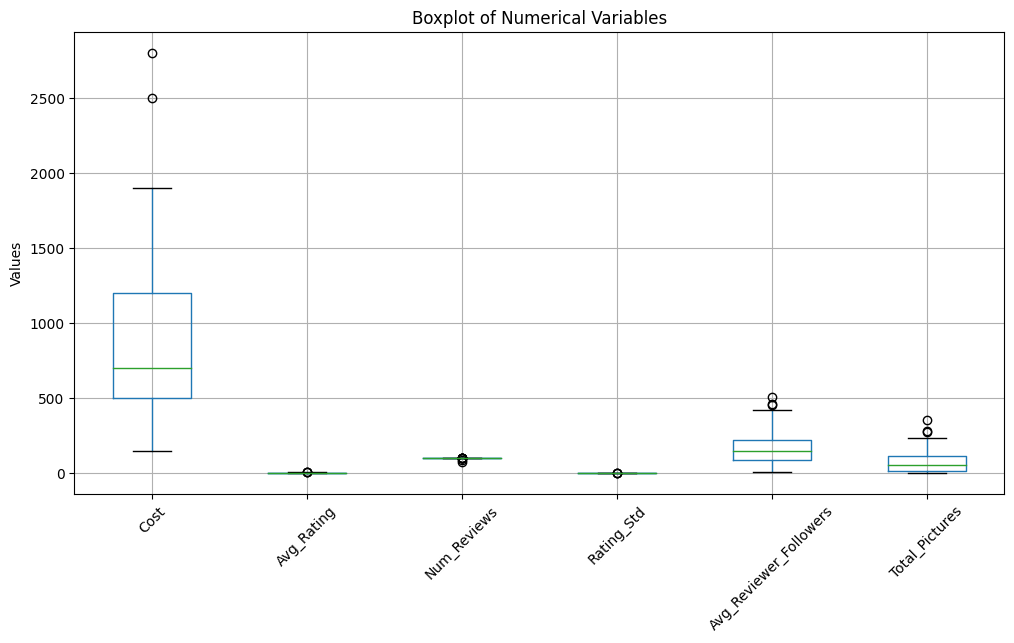

In [41]:
# Numerical columns used for outlier detection
numeric_columns = [
    'Cost',
    'Avg_Rating',
    'Num_Reviews',
    'Rating_Std',
    'Avg_Reviewer_Followers',
    'Total_Pictures'
]

# Boxplots for numerical variables
df[numeric_columns].boxplot(figsize=(12, 6))

plt.xticks(rotation=45)
plt.title('Boxplot of Numerical Variables')
plt.ylabel('Values')

plt.show()

In [42]:
# Remove outliers using IQR method

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_limit) &
        (df[column] <= upper_limit)
    ]

print("Shape after outlier treatment:", df.shape)

Shape after outlier treatment: (79, 11)


##### What all outlier treatment techniques have you used and why did you use those techniques?


IQR (Interquartile Range) Method:
The IQR method was used to identify extreme observations in numerical variables.

It was selected because it is simple and robust to skewed data. This is particularly useful for variables such as Cost, Total_Pictures and Avg_Reviewer_Followers, which may contain extreme values.

Important: Don't automatically remove outliers just because they exist. In restaurant data, an expensive restaurant or a restaurant with many pictures can be a genuine observation. If removing outliers causes too much data loss, we can use capping instead.

### 3. Categorical Encoding

Important Categorical variable is Cuisines

In [43]:
#Create variable for cuisines count
# Number of cuisines served
df['Cuisine_Count'] = df['Cuisines'].str.count(',') + 1

In [44]:
# One-hot encode cuisines
cuisine_encoded = pd.get_dummies(
    df['Cuisines'],
    prefix='Cuisine'
)

cuisine_encoded.head()

,"Cuisine_American, Chinese, North Indian, Kebab, South Indian","Cuisine_American, Wraps, Desserts","Cuisine_Andhra, Biryani, Hyderabadi, North Indian","Cuisine_Andhra, North Indian, Chinese","Cuisine_Andhra, South Indian, North Indian",Cuisine_Asian,"Cuisine_Asian, Continental, North Indian, Chinese, Mediterranean","Cuisine_Asian, Mediterranean, North Indian, Desserts","Cuisine_Asian, Sushi","Cuisine_Asian, Thai, Chinese, Sushi, Momos",...,"Cuisine_North Indian, Italian, Finger Food","Cuisine_North Indian, Japanese, Italian, Salad, Sushi","Cuisine_North Indian, Mediterranean, European","Cuisine_North Indian, Mughlai","Cuisine_North Indian, Mughlai, Beverages","Cuisine_North Indian, South Indian","Cuisine_Seafood, Goan, North Indian, Continental, Asian","Cuisine_South Indian, North Indian, Chinese","Cuisine_Street Food, Arabian","Cuisine_Street Food, North Indian, Fast Food"
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


#### What all categorical encoding techniques have you used & why did you use those techniques?

One-Hot Encoding was used for categorical variables.

One-hot encoding converts categories into numerical columns containing 0 and 1. This is suitable for clustering because machine-learning algorithms require numerical input.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

reviews_clean['Review'] column contains the actual customer review text.
We'll create a separate text-processing dataset:

In [45]:
text_data = reviews_clean[['Restaurant', 'Review']].copy()

text_data.head()

,Restaurant,Review
0,Beyond Flavours,"The ambience was good, food was quite good . h..."
1,Beyond Flavours,Ambience is too good for a pleasant evening. S...
2,Beyond Flavours,A must try.. great food great ambience. Thnx f...
3,Beyond Flavours,Soumen das and Arun was a great guy. Only beca...
4,Beyond Flavours,Food is good.we ordered Kodi drumsticks and ba...


#### 1. Expand Contraction

In [46]:
# Expand common contractions

def expand_contractions(text):

    contractions = {
        "don't": "do not",
        "can't": "cannot",
        "won't": "will not",
        "isn't": "is not",
        "wasn't": "was not",
        "didn't": "did not",
        "doesn't": "does not",
        "couldn't": "could not",
        "wouldn't": "would not",
        "shouldn't": "should not",
        "it's": "it is",
        "that's": "that is",
        "i'm": "i am",
        "you're": "you are",
        "we're": "we are",
        "they're": "they are"
    }

    for short, full in contractions.items():
        text = text.replace(short, full)

    return text

In [47]:
text_data['Review'] = text_data['Review'].apply(expand_contractions)

Example:<br>
don't → do not<br>
can't → cannot<br>
it's → it is<br>
won't → will not<br>

#### 2. Lower Casing

In [48]:
text_data['Review'] = text_data['Review'].str.lower()

Lower casing ensures that words such as:

Good<br>
GOOD<br>
good<br>

are treated as the same word.

#### 3. Removing Punctuations

In [49]:
import string

text_data['Review'] = text_data['Review'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

#### 4. Removing URLs & Removing words and digits contain digits.

In [50]:
import re

def remove_urls_and_digits(text):

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'\w*\d\w*', '', text)

    return text

In [51]:
text_data['Review'] = text_data['Review'].apply(
    remove_urls_and_digits
)

URLs and words containing numbers generally do not provide useful information for basic sentiment analysis and text clustering.

#### 5. Removing Stopwords & Removing White spaces

In [52]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aneeqaqwath/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [53]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [54]:
def remove_stopwords(text):

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [55]:
text_data['Review'] = text_data['Review'].apply(
    remove_stopwords
)

In [56]:
text_data['Review'] = text_data['Review'].str.strip()

#### 6. Rephrase Text

No automatic text rephrasing was performed because the original customer reviews were retained to preserve the actual opinions and sentiments expressed by the reviewers. Rephrasing could change the original meaning of the reviews.

#### 7. Tokenization

In [57]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/aneeqaqwath/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/aneeqaqwath/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [58]:
from nltk.tokenize import word_tokenize

text_data['Tokens'] = text_data['Review'].apply(
    word_tokenize
)

Tokenization converts sentences into individual words that can be processed by NLP algorithms.<br>
"food was very good"->['food', 'was', 'very', 'good']

#### 8. Text Normalization

In [59]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/aneeqaqwath/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/aneeqaqwath/nltk_data...


True

In [60]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_words(words):

    return [
        lemmatizer.lemmatize(word)
        for word in words
    ]

In [61]:
text_data['Tokens'] = text_data['Tokens'].apply(
    lemmatize_words
)

##### Which text normalization technique have you used and why?

Lemmatization was used because it converts words into their meaningful base form.<br>
restaurants → restaurant<br>
reviews → review<br>
serving → serving<br>

#### 9. Part of speech tagging

In [62]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/aneeqaqwath/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [63]:
from nltk import pos_tag

text_data['POS_Tags'] = text_data['Tokens'].apply(
    pos_tag
)

POS tagging identifies the grammatical role of each word. It can be useful in more advanced sentiment and NLP analysis.<br>
good → adjective<br>
food → noun<br>
served → verb<br>

#### 10. Text Vectorization

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [67]:
text_data['Clean_Review'] = text_data['Tokens'].apply(
    lambda x: ' '.join(x)
)

In [68]:
tfidf = TfidfVectorizer(
    max_features=1000
)

tfidf_matrix = tfidf.fit_transform(
    text_data['Clean_Review']
)

print(tfidf_matrix.shape)

(9954, 1000)


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency–Inverse Document Frequency) was used to convert customer reviews into numerical features.

TF-IDF gives higher importance to words that are important in a particular review but less common across all reviews.

For example, words that occur in almost every review such as "food" may receive less importance, while more specific words may receive higher weights.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***